In [11]:
# https://github.com/robaita/introduction_to_machine_learning/raw/main/dataset.zip

In [12]:
!unzip -o '/content/dataset (3).zip'

Archive:  /content/dataset (3).zip
  inflating: dataset/faces/Aamir/face_101.jpg  
  inflating: dataset/faces/Aamir/face_102.jpg  
  inflating: dataset/faces/Aamir/face_106.jpg  
  inflating: dataset/faces/Aamir/face_107.jpg  
  inflating: dataset/faces/Aamir/face_114.jpg  
  inflating: dataset/faces/Aamir/face_115.jpg  
  inflating: dataset/faces/Aamir/face_117.jpg  
  inflating: dataset/faces/Aamir/face_118.jpg  
  inflating: dataset/faces/Aamir/face_119.jpg  
  inflating: dataset/faces/Aamir/face_123.jpg  
  inflating: dataset/faces/Aamir/face_125.jpg  
  inflating: dataset/faces/Aamir/face_127.jpg  
  inflating: dataset/faces/Aamir/face_13.jpg  
  inflating: dataset/faces/Aamir/face_17.jpg  
  inflating: dataset/faces/Aamir/face_20.jpg  
  inflating: dataset/faces/Aamir/face_21.jpg  
  inflating: dataset/faces/Aamir/face_25.jpg  
  inflating: dataset/faces/Aamir/face_27.jpg  
  inflating: dataset/faces/Aamir/face_35.jpg  
  inflating: dataset/faces/Aamir/face_38.jpg  
  inflating: 

--2026-01-20 07:14:28--  https://github.com/robaita/introduction_to_machine_learning/raw/main/dataset.zip
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/robaita/introduction_to_machine_learning/main/dataset.zip [following]
--2026-01-20 07:14:28--  https://raw.githubusercontent.com/robaita/introduction_to_machine_learning/main/dataset.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19261180 (18M) [application/zip]
Saving to: ‘dataset.zip’

dataset.zip         100%[===================>]  18.37M  --.-KB/s    in 0.1s    

2026-01-20 07:14:28 (155 MB/s) - ‘dataset.zip’ saved [19261180/19261180]


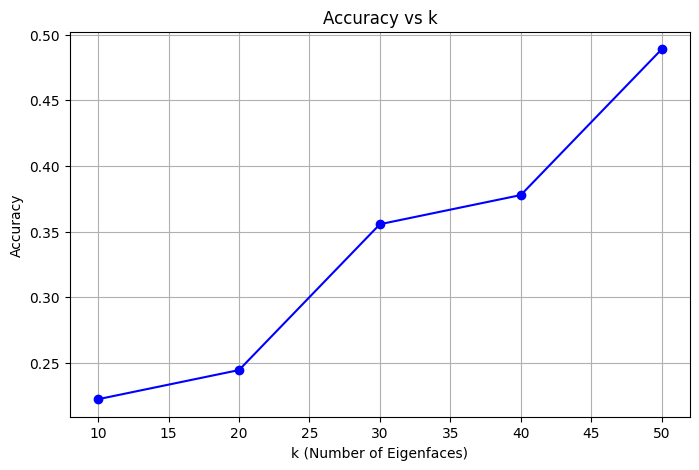

In [13]:
# -------------------------------------------------------------
# STEP 1: DOWNLOAD AND UNZIP DATASET
# -------------------------------------------------------------
!wget https://github.com/robaita/introduction_to_machine_learning/raw/main/dataset.zip
!unzip -o dataset.zip

# -------------------------------------------------------------
# STEP 2: IMPORT LIBRARIES AND DEFINE CONSTANTS
# -------------------------------------------------------------
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

DATASET_PATH = "dataset/faces"
IMG_SIZE = (64, 64)  # Resize dimensions for uniformity

# -------------------------------------------------------------
# STEP 3: LOAD AND PREPROCESS DATA
# -------------------------------------------------------------
def load_faces(path):
    X = []
    y = []
    persons = sorted(os.listdir(path))
    num_classes = len(persons)

    for idx, person in enumerate(persons):
        person_path = os.path.join(path, person)
        if not os.path.isdir(person_path): continue

        for img_name in os.listdir(person_path):
            img_path = os.path.join(person_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, IMG_SIZE)
                X.append(img.flatten())
                y.append(idx)

    return np.array(X), np.array(y), num_classes

X, y, num_classes = load_faces(DATASET_PATH)
print(f"Total images loaded: {len(X)} across {num_classes} classes.")

# -------------------------------------------------------------
# STEP 4: DEFINE ANN CLASS (From Notebook Logic)
# -------------------------------------------------------------
class ANN:
    def __init__(self, input_size, hidden_size, output_size):
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def train(self, X, y, epochs, lr):
        m = X.shape[0]
        y_one_hot = np.eye(num_classes)[y]

        for i in range(epochs):
            # Forward pass
            z1 = np.dot(X, self.W1) + self.b1
            a1 = self.sigmoid(z1)
            z2 = np.dot(a1, self.W2) + self.b2
            a2 = self.softmax(z2)

            # Backward pass
            dz2 = a2 - y_one_hot
            dW2 = np.dot(a1.T, dz2) / m
            db2 = np.sum(dz2, axis=0, keepdims=True) / m

            da1 = np.dot(dz2, self.W2.T)
            dz1 = da1 * (a1 * (1 - a1))
            dW1 = np.dot(X.T, dz1) / m
            db1 = np.sum(dz1, axis=0, keepdims=True) / m

            # Update weights
            self.W1 -= lr * dW1
            self.b1 -= lr * db1
            self.W2 -= lr * dW2
            self.b2 -= lr * db2

    def predict(self, X):
        a1 = self.sigmoid(np.dot(X, self.W1) + self.b1)
        a2 = self.softmax(np.dot(a1, self.W2) + self.b2)
        return np.argmax(a2, axis=1)

# -------------------------------------------------------------
# STEP 5: EIGENFACES (PCA) AND EXPERIMENTATION
# -------------------------------------------------------------
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Compute Mean Face and Covariance
mean_face = np.mean(X_train, axis=0)
X_centered = X_train - mean_face
cov_matrix = np.dot(X_centered, X_centered.T)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort eigenvectors
idx = eigenvalues.argsort()[::-1]
eigenvectors = eigenvectors[:, idx]

# Experiment with different k values
k_values = [10, 20, 30, 40, 50]
accuracy_list = []

for k in k_values:
    # Project data to k eigenfaces
    U = np.dot(X_centered.T, eigenvectors[:, :k])
    U_norm = U / np.linalg.norm(U, axis=0)

    Omega_train = np.dot(X_centered, U_norm)
    Omega_test = np.dot(X_test - mean_face, U_norm)

    # Normalize projection for ANN
    mean_omega = np.mean(Omega_train, axis=0)
    std_omega = np.std(Omega_train, axis=0)
    Omega_train_norm = (Omega_train - mean_omega) / std_omega
    Omega_test_norm = (Omega_test - mean_omega) / std_omega

    # Train and Evaluate
    ann = ANN(k, 50, num_classes)
    ann.train(Omega_train_norm, y_train, epochs=500, lr=0.1)

    preds = ann.predict(Omega_test_norm)
    acc = np.mean(preds == y_test)
    accuracy_list.append(acc)
    print(f"k={k}, Accuracy={acc:.2f}")

# -------------------------------------------------------------
# STEP 6: PLOT RESULTS
# -------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracy_list, marker='o', linestyle='-', color='b')
plt.xlabel("k (Number of Eigenfaces)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs k")
plt.grid()
plt.show()